# Import des librairies et packages

In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from src.import_.read_file import  read_file, df_dtypes

from src.exploratory.explore_data import show_values_counts_columns, analyse_univariee_qualitative, describe_variables_numeriques, controle_regroupements_modalites
from src.exploratory.plots import plot_pareto_modalites, plot_boxplot_and_hist, plot_target_dpe

from src.prepro.nettoyage import nettoyage_metier
from src.prepro.regrouper_modalites import creer_target_dpe_4_classes
from src.prepro.modalite_groupings import MODALITES_GROUPINGS
from src.prepro.regrouper_modalites import appliquer_regroupements_modalites

In [3]:
pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(-1)
pl.Config.set_fmt_str_lengths(100)

polars.config.Config

In [4]:
PATH_DATA = "resources/dpe_hauts_de_france_2025-07-01_to_2025-12-31_half.csv"
TARGET = "etiquette_dpe"
CLASSES_DPE = ["A", "B", "C", "D", "E", "F", "G"]

DPE_COLORS = {
    "A": "#008A4B",
    "B": "#58B957",
    "C": "#C7D93D",
    "D": "#F4E04D",
    "E": "#F5A623",
    "F": "#E85D27",
    "G": "#C62828",
}

# Lecture et Visualisation des données

In [5]:
data, num_cols, cat_cols = read_file(PATH_DATA, TARGET)
df = data.clone()

### Import des données

Le jeu de données contient **57826 lignes** et **46 colonnes**.

### Réduction de la taille du DataFrame

Taille du DataFrame avant réduction : **37.71 MB**

Taille du DataFrame après réduction : **34.35 MB**

Réduction mémoire : **8.92%**

### Aperçu des données importées

etiquette_dpe,numero_dpe,date_etablissement_dpe,code_region_ban,code_departement_ban,code_postal_ban,code_insee_ban,nom_commune_ban,zone_climatique,classe_altitude,type_batiment,methode_application_dpe,periode_construction,annee_construction,surface_habitable_immeuble,nombre_niveau_immeuble,nombre_appartement,numero_etage_appartement,hauteur_sous_plafond,classe_inertie_batiment,qualite_isolation_enveloppe,qualite_isolation_murs,qualite_isolation_menuiseries,qualite_isolation_plancher_bas,qualite_isolation_plancher_haut_comble_perdu,type_installation_chauffage,type_installation_chauffage_n1,configuration_installation_chauffage_n1,type_generateur_chauffage_principal,type_generateur_n1_installation_n1,type_energie_principale_chauffage,type_energie_generateur_n1_installation_n1,type_emetteur_installation_chauffage_n1,usage_generateur_n1_installation_n1,type_installation_ecs,type_installation_ecs_n1,configuration_installation_ecs_n1,type_generateur_n1_ecs_n1,type_generateur_chauffage_principal_ecs,type_energie_principale_ecs,type_energie_generateur_n1_ecs_n1,usage_generateur_n1_ecs_n1,volume_stockage_generateur_n1_ecs_n1,ventilation_posterieure_2012,type_installation_solaire_n1,production_electricite_pv_kwhep_par_an
str,str,str,u8,u8,u32,u32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f32,u8,str,f32
"""C""","""2559E3504406H""","""2025-11-05""",32,59,59320,59286,"""Haubourdin""","""H1a""","""inférieur à 400m""","""maison""","""dpe maison individuelle""","""1948-1974""",null,null,null,null,0.0,2.5,"""Lourde""","""très bonne""","""très bonne""","""bonne""","""très bonne""","""très bonne""",null,"""installation individuelle""","""Installation de chauffage simple""","""Chaudière gaz à condensation après 2015""","""Chaudière gaz à condensation après 2015""","""Gaz naturel""","""Gaz naturel""","""Radiateur monotube sans robinet thermostatique sur réseau individuel eau chaude basse ou moyenne tem…","""chauffage + ecs""",null,"""installation individuelle""","""Un seul système d'ECS sans solaire""","""Chaudière gaz à condensation après 2015""","""Chaudière gaz à condensation après 2015""","""Gaz naturel""","""Gaz naturel""","""chauffage + ecs""",0.0,1,"""Non affecté""",0.0
"""F""","""2559E2432688J""","""2025-07-24""",32,59,59360,59136,"""Le Cateau-Cambrésis""","""H1a""","""inférieur à 400m""","""maison""","""dpe maison individuelle""","""avant 1948""",null,null,null,null,0.0,2.6,"""Lourde""","""insuffisante""","""insuffisante""","""moyenne""","""insuffisante""",null,null,"""installation individuelle""","""Installation de chauffage simple""",null,"""Chaudière gaz à condensation 2001-2015""","""Gaz naturel""","""Gaz naturel""","""Radiateur bitube avec robinet thermostatique sur réseau individuel eau chaude haute température(sup …","""chauffage + ecs""",null,"""installation individuelle""","""Un seul système d'ECS sans solaire""","""Chaudière gaz à condensation 2001-2015""",null,"""Gaz naturel""","""Gaz naturel""","""chauffage + ecs""",0.0,0,"""Non affecté""",0.0
"""C""","""2502E3087497D""","""2025-09-30""",32,2,2170,2558,"""Le Nouvion-en-Thiérache""","""H1a""","""inférieur à 400m""","""appartement""","""dpe appartement individuel""","""1978-1982""",null,512.299988,null,1.0,0.0,2.5,"""Moyenne""","""très bonne""","""insuffisante""","""très bonne""","""insuffisante""",null,"""individuel""","""installation individuelle""","""Installation de chauffage simple""",null,"""Panneau rayonnant électrique NFC, NF** et NF***""","""Électricité""","""Électricité""","""Panneau rayonnant NFC, NF** et NF***""","""chauffage""","""individuel""","""installation individuelle""","""Un seul système d'ECS sans solaire""","""CET sur air ambiant (sur local non chauffé) après 2014""",null,"""Électricité""","""Électricité""","""ecs""",150.0,1,"""Non affecté""",0.0
"""E""","""2502E3013330O""","""2025-09-23""",32,2,2000,2408,"""Laon""","""H1a""","""inférieur à 400m""","""maison"""

### Que vaut notre target ?

etiquette_dpe,Pourcentage
str,f64
"""A""",0.94
"""B""",3.26
"""C""",36.12
"""D""",35.52
"""E""",15.03
"""F""",6.1
"""G""",3.03


In [6]:
df_dtypes(df)

### Les différents types du df

Variables,Types
str,str
"""etiquette_dpe""","""String"""
"""numero_dpe""","""String"""
"""date_etablissement_dpe""","""String"""
"""code_region_ban""","""UInt8"""
"""code_departement_ban""","""UInt8"""
"""code_postal_ban""","""UInt32"""
"""code_insee_ban""","""UInt32"""
"""nom_commune_ban""","""String"""
"""zone_climatique""","""String"""


### Catégorisation des types du df

Type,Nombre,Pourcentage
object,i64,f64
String,33,71.74
UInt8,3,6.52
UInt32,2,4.35
Float32,8,17.39


In [7]:
show_values_counts_columns(df)

### Modalités distinctes et valeurs manquantes par variable

Variable,Nombre de lignes,% valeurs manquantes,Modalités distinctes,% modalités distinctes
str,i64,f64,i64,f64
"""nombre_niveau_immeuble""",57826,76.42,19,0.03
"""surface_habitable_immeuble""",57826,68.46,3858,6.67
"""type_generateur_chauffage_principal_ecs""",57826,67.75,73,0.13
"""type_generateur_chauffage_principal""",57826,67.67,93,0.16
"""qualite_isolation_plancher_haut_comble_perdu""",57826,52.86,4,0.01
"""annee_construction""",57826,51.93,204,0.35
"""nombre_appartement""",57826,50.91,135,0.23
"""type_installation_chauffage""",57826,47.75,3,0.01
"""type_installation_ecs""",57826,47.75,3,0.01


# Première suppression de variables

In [8]:
var_to_drop = ["nombre_niveau_immeuble", "surface_habitable_immeuble", "type_generateur_chauffage_principal_ecs", "type_generateur_chauffage_principal", "qualite_isolation_plancher_haut_comble_perdu", "annee_construction", "nombre_appartement", "type_installation_chauffage", "type_installation_ecs", ]

var_const = ["numero_dpe"]

var_dpe = ["methode_application_dpe", "date_etablissement_dpe"]

var_to_drop = [*var_to_drop, *var_const, *var_dpe]

cat_cols = list(set(cat_cols) - set(var_to_drop))
num_cols = list(set(num_cols) - set(var_to_drop))

In [9]:
df = df.drop(var_to_drop)
df.shape

(57826, 34)

In [10]:
VAR_ID = ["code_region_ban", "code_departement_ban", "code_postal_ban", "code_insee_ban", "nom_commune_ban"
]

CAT_VAR_TO_ANALYSE = ["zone_climatique", "type_batiment", "type_energie_principale_chauffage"]

NUM_VAR_TO_ANALYSE = ["numero_etage_appartement", "production_electricite_pv_kwhep_par_an", "hauteur_sous_plafond"]


# Analyse univariée

## Variables catégorielles 

In [11]:
analyse_univariee_qualitative(df, col="zone_climatique")

## Analyse univariée : `zone_climatique`


        - Nombre de lignes : **57826**
        - Nombre de modalités distinctes : **8**
        - Pourcentage de valeurs manquantes : **0.0 %**
        

zone_climatique,Pourcentage
str,f64
"""H1a""",99.86
"""H3""",0.05
"""H1b""",0.03
"""H1c""",0.03
"""H2a""",0.01
"""H2c""",0.01
"""H2b""",0.01
"""H2d""",0.0


In [12]:
analyse_univariee_qualitative(df, col="type_energie_principale_chauffage")

## Analyse univariée : `type_energie_principale_chauffage`


        - Nombre de lignes : **57826**
        - Nombre de modalités distinctes : **11**
        - Pourcentage de valeurs manquantes : **0.0 %**
        

type_energie_principale_chauffage,Pourcentage
str,f64
"""Gaz naturel""",53.58
"""Électricité""",31.57
"""Réseau de Chauffage urbain""",7.89
"""Fioul domestique""",3.22
"""Bois – Granulés (pellets) ou briquettes""",1.74
"""Bois – Bûches""",1.49
"""GPL""",0.3
"""Charbon""",0.1
"""Propane""",0.09


In [13]:
VAR_DOUBLONS = ["type_energie_generateur_n1_installation_n1", "type_energie_generateur_n1_ecs_n1"]

In [14]:
df.select(
    [
        pl.len().alias("nb_lignes"),

        (
            pl.col("type_energie_principale_chauffage")
            == pl.col("type_energie_generateur_n1_installation_n1")
        )
        .sum()
        .alias("nb_identiques"),

        (
            pl.col("type_energie_principale_chauffage")
            != pl.col("type_energie_generateur_n1_installation_n1")
        )
        .sum()
        .alias("nb_differentes"),

        pl.col("type_energie_principale_chauffage").null_count()
        .alias("null_principale_chauffage"),

        pl.col("type_energie_generateur_n1_installation_n1").null_count()
        .alias("null_generateur_n1"),
    ]
)

nb_lignes,nb_identiques,nb_differentes,null_principale_chauffage,null_generateur_n1
u32,u32,u32,u32,u32
57826,57522,278,0,26


In [15]:
df.select(
    [
        pl.len().alias("nb_lignes"),

        (
            pl.col("type_energie_principale_ecs")
            == pl.col("type_energie_generateur_n1_ecs_n1")
        )
        .sum()
        .alias("nb_identiques"),

        (
            pl.col("type_energie_principale_ecs")
            != pl.col("type_energie_generateur_n1_ecs_n1")
        )
        .sum()
        .alias("nb_differentes"),

        pl.col("type_energie_principale_ecs").null_count()
        .alias("null_principale_chauffage"),

        pl.col("type_energie_generateur_n1_ecs_n1").null_count()
        .alias("null_generateur_n1"),
    ]
)

nb_lignes,nb_identiques,nb_differentes,null_principale_chauffage,null_generateur_n1
u32,u32,u32,u32,u32
57826,57557,42,0,227


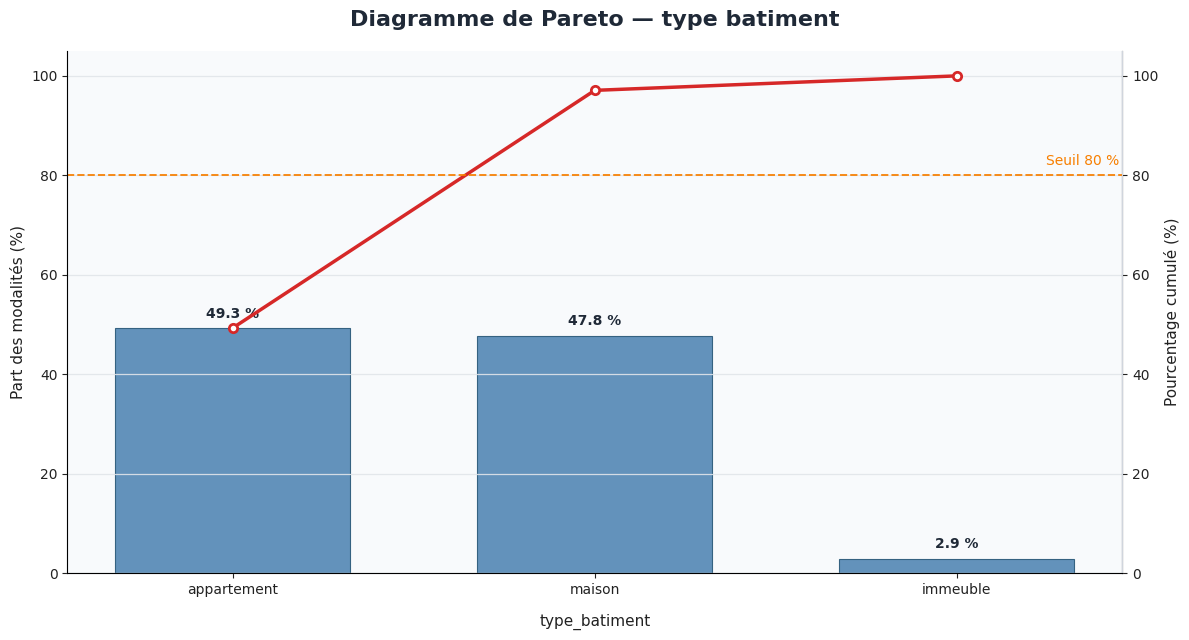

WindowsPath('src/plots/cat/pareto_type_batiment.png')

In [16]:
plot_pareto_modalites(df, col="type_batiment", top_n=10)

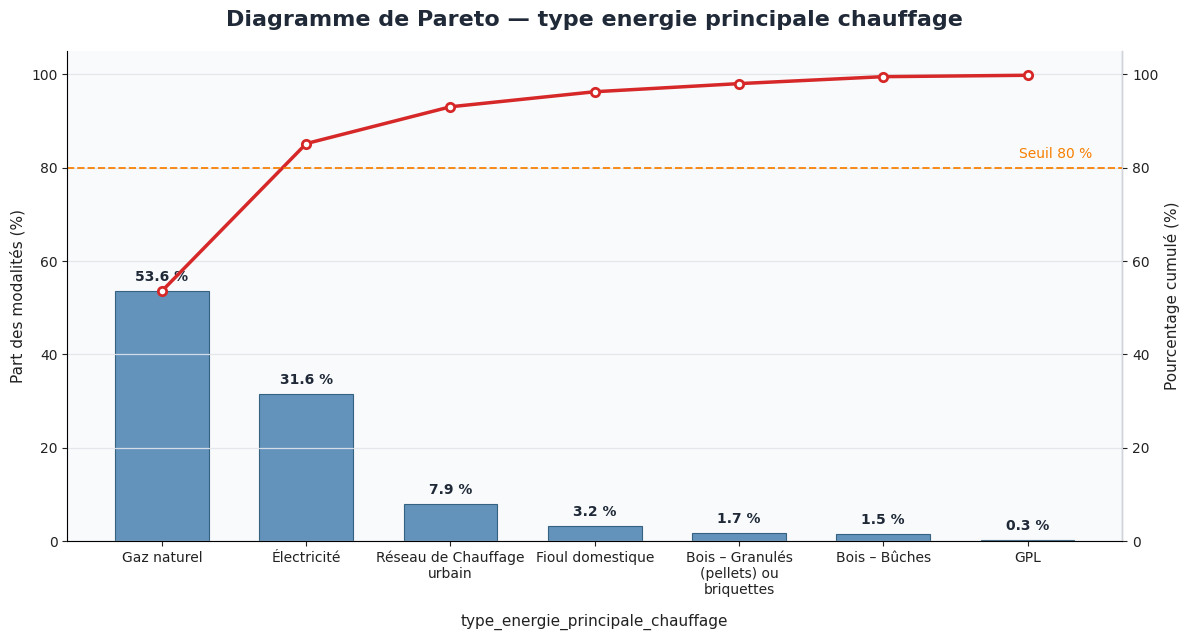

WindowsPath('src/plots/cat/pareto_type_energie_principale_chauffage.png')

In [17]:
plot_pareto_modalites(df, col="type_energie_principale_chauffage", top_n=7)

In [ ]:
df = df.drop(VAR_DOUBLONS)

## Variables numériques

In [18]:
var_bianire = ["ventilation_posterieure_2012"]

num_cols_sans_id_var = list(set(num_cols) - {*var_bianire, *VAR_ID})
outlier_cols = describe_variables_numeriques(df, num_cols_sans_id_var)


### Resume statistique des variables numériques

colonne,count,missing_count,missing_%,nb_unique,mean,std,min,q1,median,q3,max,iqr,borne_basse,borne_haute,outlier_count,outlier_%
str,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64
"""hauteur_sous_plafond""",57826,0,0.0,61,2.562,1.727,1.0,2.5,2.5,2.5,240.0,0.0,2.5,2.5,16546,28.61
"""numero_etage_appartement""",51558,6268,10.84,19,0.15,0.681,-2.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,3493,6.04
"""production_electricite_pv_kwhep_par_an""",57826,0,0.0,399,42.724,1980.189,0.0,0.0,0.0,0.0,460380.8125,0.0,0.0,0.0,586,1.01
"""volume_stockage_generateur_n1_ecs_n1""",57599,227,0.39,773,93.848,228.659,0.0,0.0,0.0,150.0,10000.0,150.0,-225.0,375.0,827,1.43


### Visualisation des variables numériques

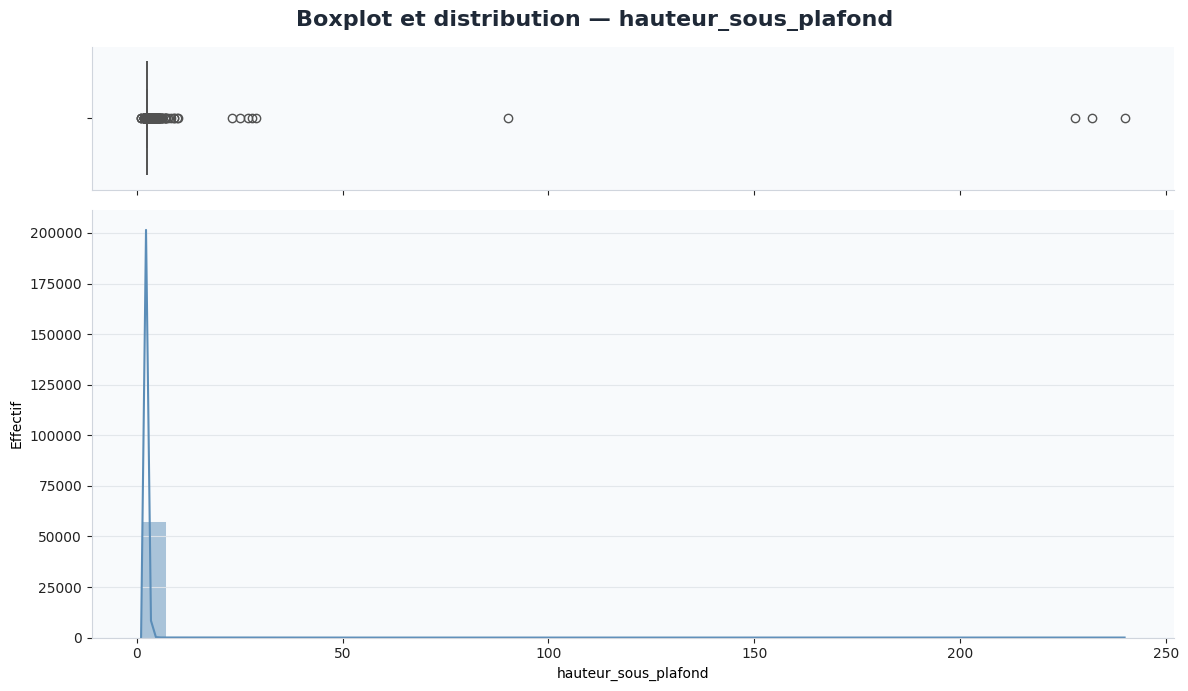

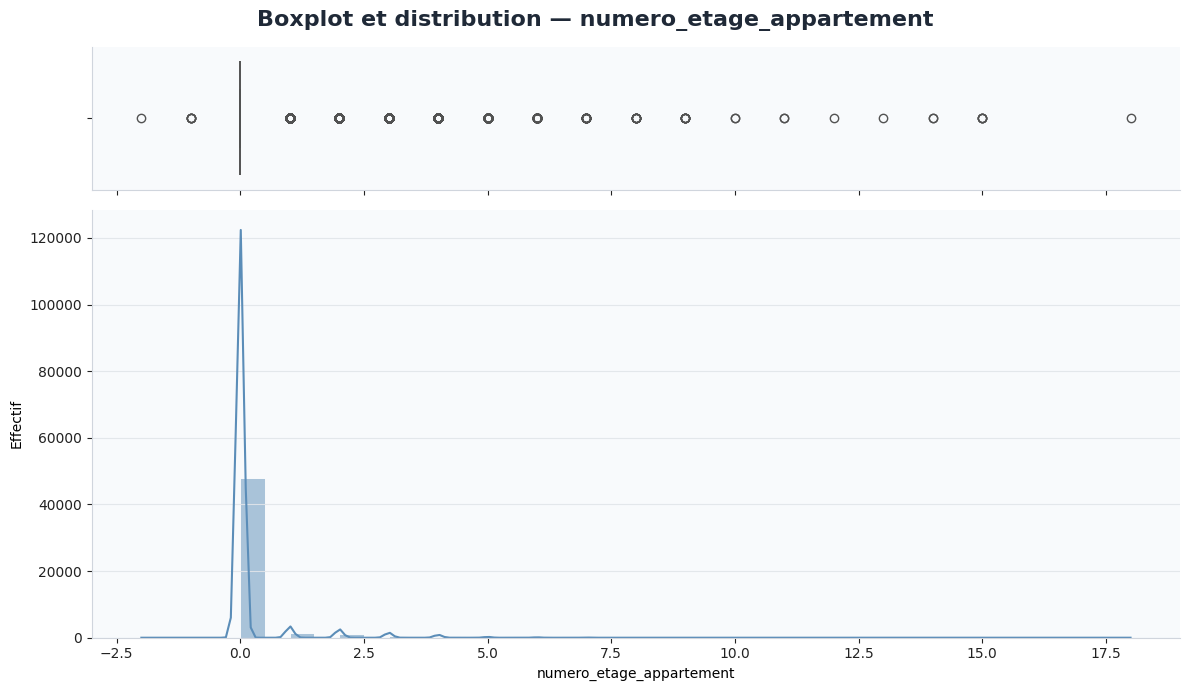

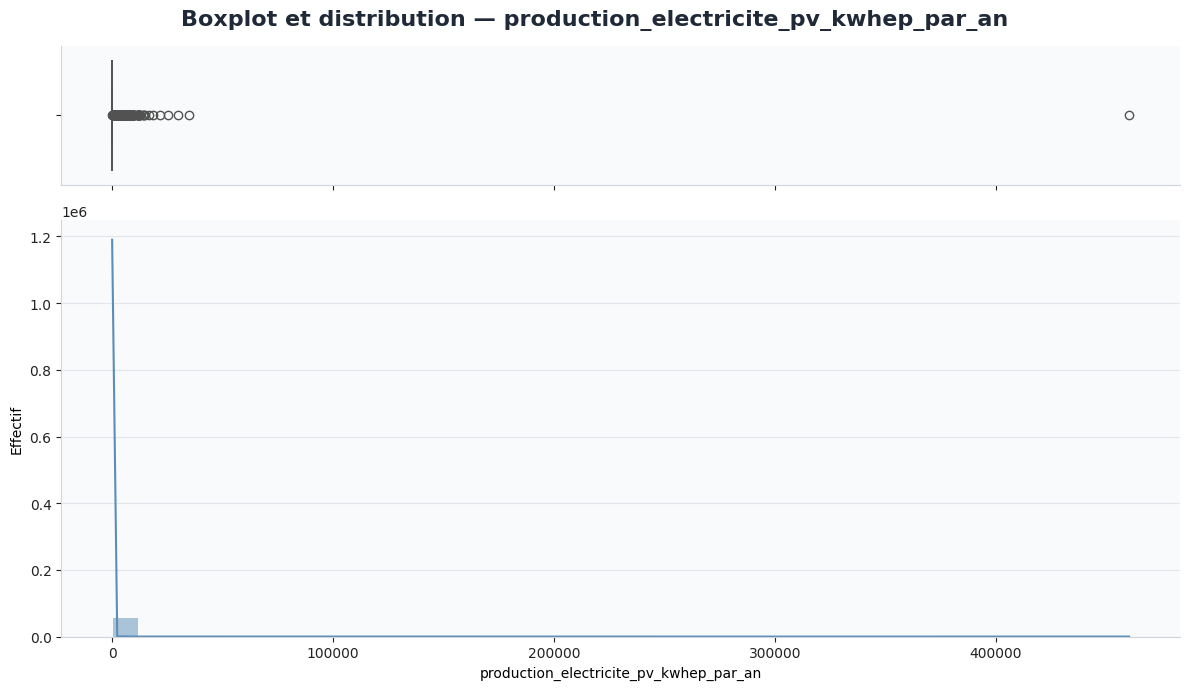

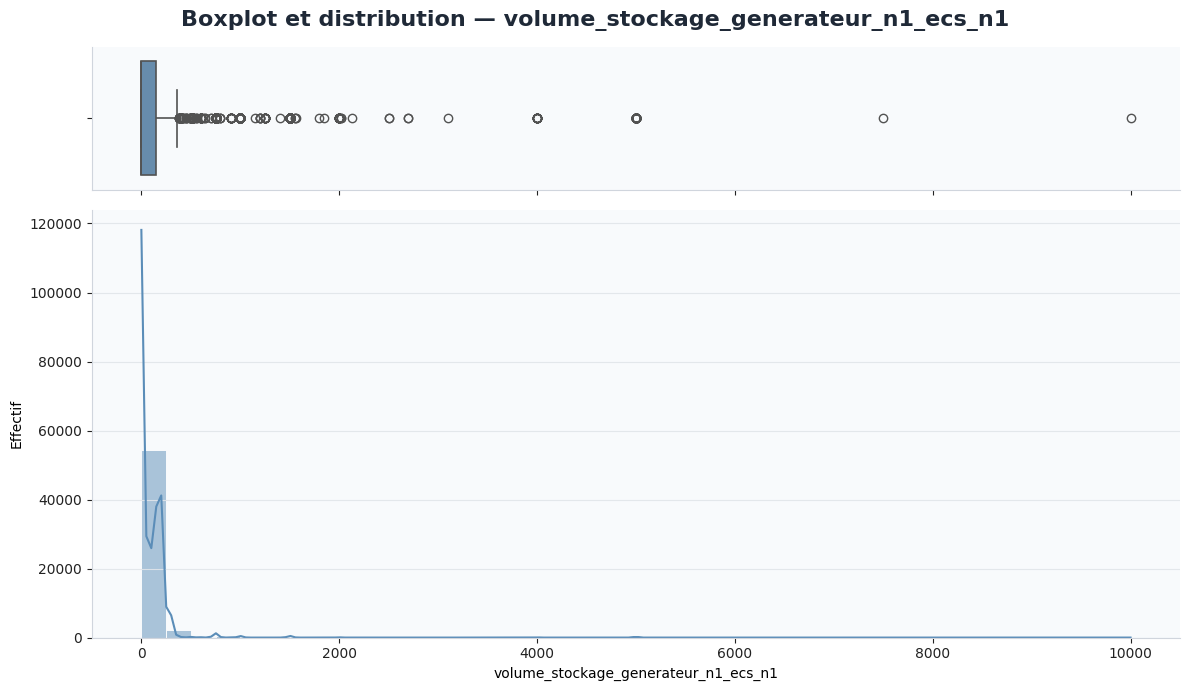

In [19]:
for col in num_cols_sans_id_var:
    plot_boxplot_and_hist(df, col)

In [20]:
df["numero_etage_appartement"].value_counts()

numero_etage_appartement,count
f32,u32
3.0,602
13.0,1
10.0,2
4.0,347
5.0,96
6.0,47
11.0,2
12.0,1
18.0,1


In [21]:
sum(df["hauteur_sous_plafond"] > 5) + sum(df["hauteur_sous_plafond"] < 1.8)

39

# Un premier nettoyage sur les variables quantitatives avant d'aller plus loin

In [22]:
df = nettoyage_metier(df)

In [23]:
df.shape

(57136, 38)

In [24]:
new_cols_num = ["hauteur_sous_plafond_corrigee"]
var_bianire = [*var_bianire, ["has_PV"]]

num_cols_sans_id_var = num_cols_sans_id_var + new_cols_num

In [25]:
outlier_cols = describe_variables_numeriques(df, num_cols_sans_id_var)

### Resume statistique des variables numériques

colonne,count,missing_count,missing_%,nb_unique,mean,std,min,q1,median,q3,max,iqr,borne_basse,borne_haute,outlier_count,outlier_%
str,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64
"""hauteur_sous_plafond""",57136,0,0.0,61,2.562,1.737,1.0,2.5,2.5,2.5,240.0,0.0,2.5,2.5,16450,28.79
"""numero_etage_appartement""",50945,6191,10.84,19,0.15,0.681,-2.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,3432,6.01
"""production_electricite_pv_kwhep_par_an""",57136,0,0.0,395,42.631,1989.096,0.0,0.0,0.0,0.0,460380.8125,0.0,0.0,0.0,582,1.02
"""volume_stockage_generateur_n1_ecs_n1""",56909,227,0.4,761,77.852,103.865,0.0,0.0,0.0,150.0,5000.0,150.0,-225.0,375.0,137,0.24
"""hauteur_sous_plafond_corrigee""",57136,0,0.0,61,2.55,0.47,1.0,2.5,2.5,2.5,90.099998,0.0,2.5,2.5,16450,28.79


### Visualisation de la variavle hauteur_sous_plafond_corrigee

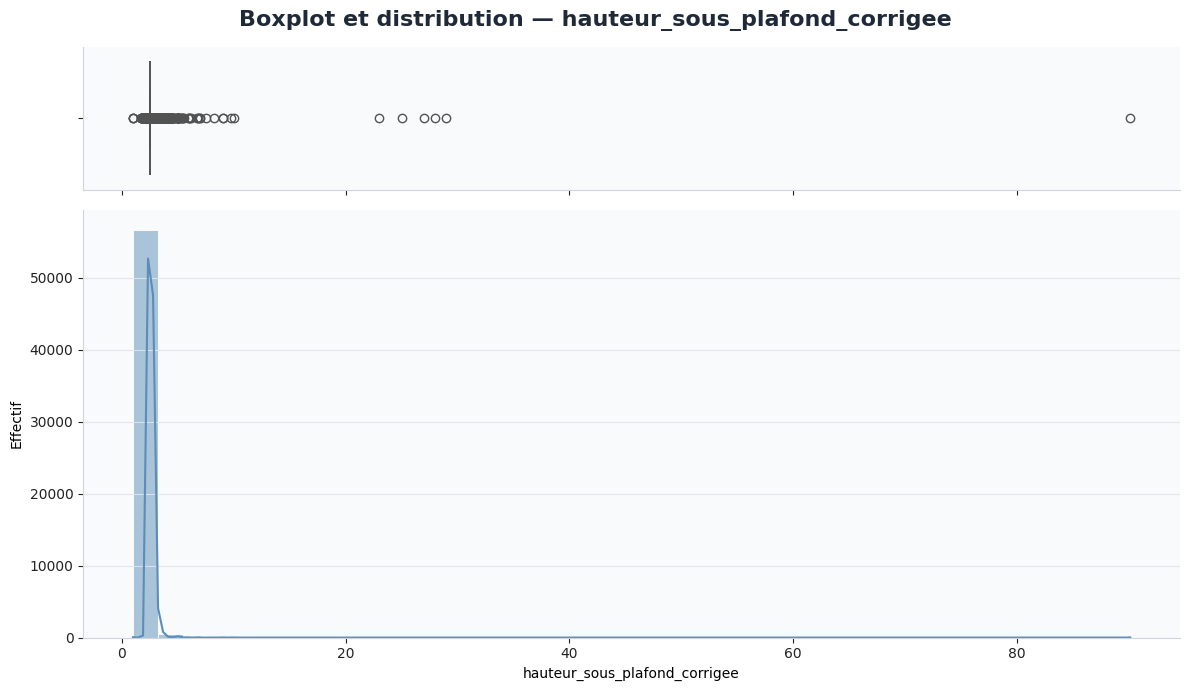

WindowsPath('src/plots/num/boxplot_distribution_hauteur_sous_plafond_corrigee.png')

In [26]:
plot_boxplot_and_hist(df, col="hauteur_sous_plafond_corrigee")

# Visualisation de la target

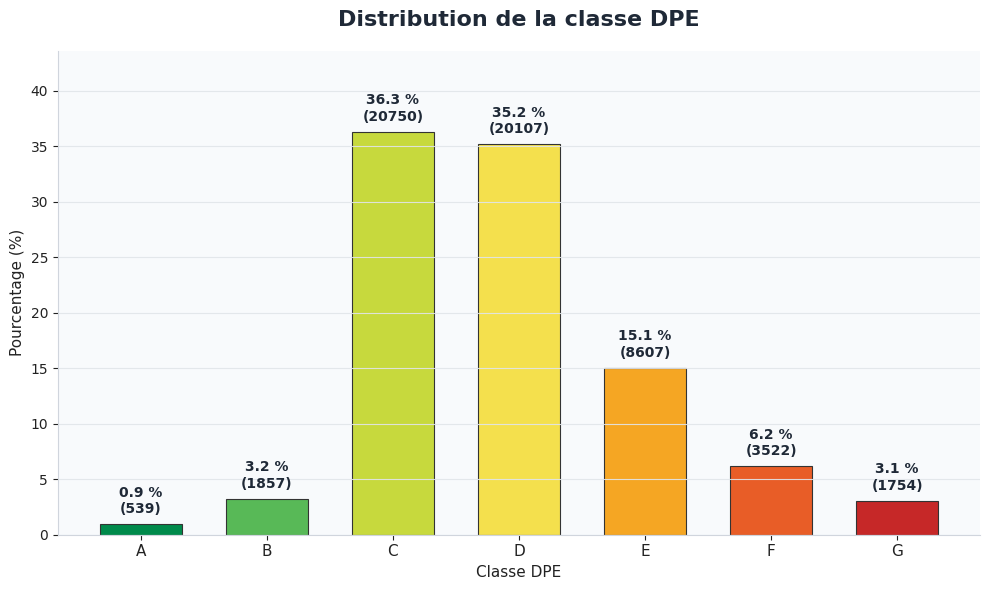

WindowsPath('src/plots/cat/distribution_etiquette_dpe.png')

In [27]:
plot_target_dpe(df, classes_dpe=CLASSES_DPE, dpe_colors=DPE_COLORS, target_col="etiquette_dpe")

# Regroupement de la target

In [28]:
df = creer_target_dpe_4_classes(df)
NEW_TARGET = "classe_dpe_4"
NEW_CLASSES_DPE = ["tres_performant", "performant", "intermediaire", "energivore"]

NEW_DPE_COLORS = {
    "tres_performant": "#008A4B",
    "performant": "#C7D93D",
    "intermediaire": "#F4E04D",
    "energivore": "#C62828",
}

### Visualisation de la nouvelle target

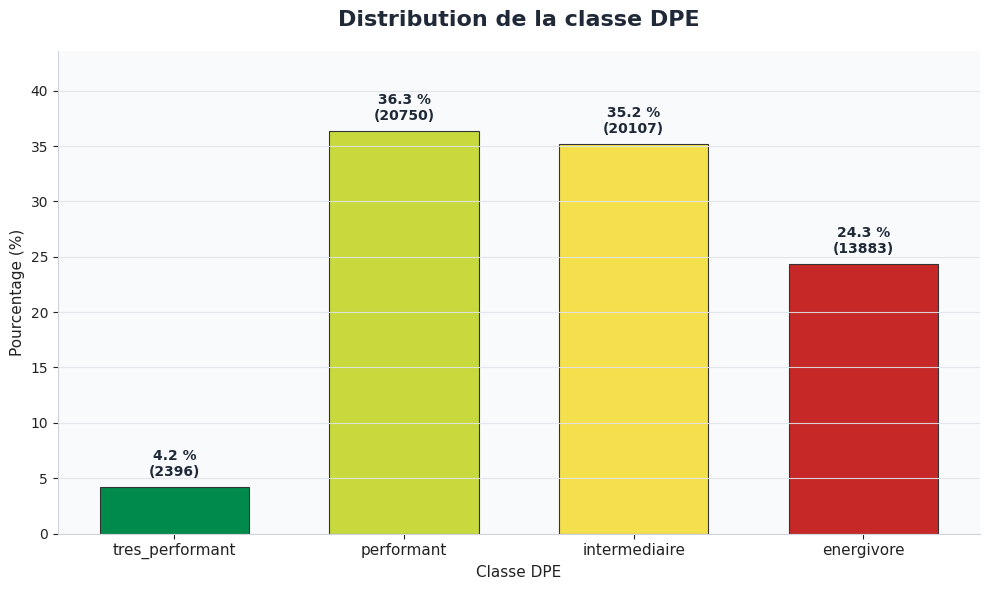

WindowsPath('src/plots/cat/distribution_classe_dpe_4.png')

In [29]:
plot_target_dpe(df, classes_dpe=NEW_CLASSES_DPE, dpe_colors=NEW_DPE_COLORS, target_col=NEW_TARGET)

# Préparation de l'analyse bivariée

## Regroupement des variables catégorielles

In [30]:
df = appliquer_regroupements_modalites(
    df=df,
    modalites_groupings=MODALITES_GROUPINGS
)

In [31]:
new_var_to_drop = list(MODALITES_GROUPINGS.keys()) + ["etiquette_dpe", "hauteur_sous_plafond"]

In [32]:
df = df.drop(list(new_var_to_drop))
df.shape

(57136, 37)

In [33]:
colonnes_quali_regroupees = [
    f"{col}_regroupee"
    for col in MODALITES_GROUPINGS.keys()
]

colonnes_quali_regroupees

['zone_climatique_regroupee',
 'type_generateur_n1_installation_n1_regroupee',
 'type_emetteur_installation_chauffage_n1_regroupee',
 'type_generateur_n1_ecs_n1_regroupee',
 'type_energie_principale_chauffage_regroupee',
 'type_energie_principale_ecs_regroupee',
 'configuration_installation_chauffage_n1_regroupee']

## Checking des regroupements

In [34]:
controle_regroupements_modalites(
    df=df,
    colonnes_regroupees=colonnes_quali_regroupees
)

colonne,nb_modalites,missing_count,missing_%,autre_count,autre_%
str,i64,i64,f64,i64,f64
"""zone_climatique_regroupee""",3,0,0.0,0,0.0
"""type_generateur_n1_installation_n1_regroupee""",14,26,0.05,0,0.0
"""type_emetteur_installation_chauffage_n1_regroupee""",13,26,0.05,0,0.0
"""type_generateur_n1_ecs_n1_regroupee""",16,227,0.4,0,0.0
"""type_energie_principale_chauffage_regroupee""",7,0,0.0,0,0.0
"""type_energie_principale_ecs_regroupee""",8,0,0.0,0,0.0
"""configuration_installation_chauffage_n1_regroupee""",7,26,0.05,0,0.0


## Filtrage pour